In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv('telco_churn.csv')

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.drop('customerID', axis=1, inplace=True)

KeyError: "['customerID'] not found in axis"

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
eksik_veriler = df.isnull().sum()
print("\n--- Sütunlardaki Eksik Değer Sayıları ---")
print(eksik_veriler[eksik_veriler > 0])


--- Sütunlardaki Eksik Değer Sayıları ---
TotalCharges    11
dtype: int64


In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [17]:
df['Churn_Label'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [20]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

/var/folders/nz/xx5vfcx52nl30cj4bhl8k__m0000gn/T/ipykernel_12872/2343363889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


Text(0, 0.5, 'Customer count')

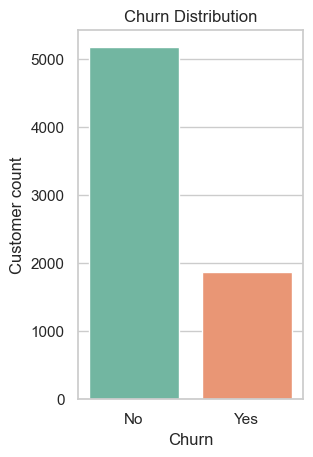

In [25]:
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.ylabel('Customer count')

In [27]:
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

Text(0.5, 0, 'Sözleşme Türü (Contract)')

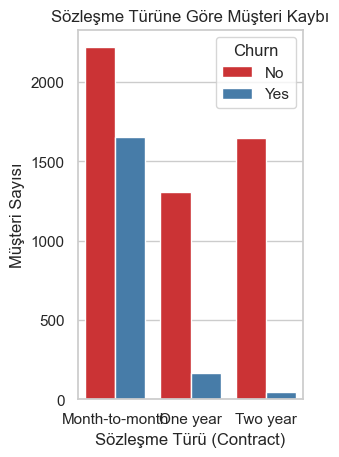

In [29]:
plt.subplot(1, 2, 2)
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Sözleşme Türüne Göre Müşteri Kaybı')
plt.ylabel('Müşteri Sayısı')
plt.xlabel('Sözleşme Türü (Contract)')

In [34]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [38]:
# 1. Hedef Değişkeni Temizleme
# Daha önce 'Churn_Label' (1 ve 0) oluşturmuştuk, artık orijinal metin 'Churn' sütununa ihtiyacımız yok.
#df.drop('Churn', axis=1, inplace=True)

# 2. Metinleri Sayılara Çevirme (One-Hot Encoding)
# pd.get_dummies fonksiyonu, metin olan tüm sütunları tespit edip her bir kategori için yeni bir 1-0 sütunu açar.
# drop_first=True parametresi, gereksiz tekrarları önleyerek modeli sade tutar.
df_encoded = pd.get_dummies(df, drop_first=True)

display(df_encoded.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Label,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
y = df_encoded['Churn_Label']
X = df_encoded.drop('Churn_Label', axis=1)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: Runti

LogisticRegression(max_iter=1000)

In [51]:
y_pred = model.predict(X_test_scaled)


/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eren/PycharmProjects/TelcoCustomer/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [55]:
print("Model Doğruluk Oranı (Accuracy):", accuracy_score(y_test, y_pred))
print("\n--- Sınıflandırma Raporu (Classification Report) ---")
print(classification_report(y_test, y_pred))

Model Doğruluk Oranı (Accuracy): 0.8069552874378992

--- Sınıflandırma Raporu (Classification Report) ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [56]:
import joblib


joblib.dump(model, 'telco_churn_model.joblib')


joblib.dump(scaler, 'telco_churn_scaler.joblib')

print("📦 Model ve Scaler başarıyla kaydedildi! PyCharm klasörünü kontrol edebilirsin.")

📦 Model ve Scaler başarıyla kaydedildi! PyCharm klasörünü kontrol edebilirsin.
